# Surface scour and the age of an unconformity

This notebook tests whether surface scour can place 5.0 Ma ice beside 0.8 Ma ice while retaining a sharp isotope step. The calculation deliberately separates two clocks: the **4.2 Myr missing-age interval** and the **time since the two packets became adjacent**. These clocks need not be equal.

Three histories are compared. Ordinary accumulation retains all intervening isochrones. Scour-only suppresses deposition from 5.0 to 0.8 Ma and therefore creates an unconformity. A recent, prescribed flow perturbation then deforms that unconformity. Material lines on the two sides of the unconformity are stored separately; no age field is interpolated across the jump.

The calculation is kinematic. Firedrake discretizes a divergence-free streamfunction flow in a 6 km by 1 km vertical flow band. It does not solve for the stress needed to produce the perturbation.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
import icepack
from firedrake import (
    RectangleMesh, VectorFunctionSpace, Function, SpatialCoordinate,
    as_vector, sin, cos, pi, div, dx, assemble
)

print(f"Firedrake {version('firedrake')} | Icepack {version('icepack')}")

Firedrake 0.14.dev0 | Icepack 1.1.0


## Two clocks and a surface-mass-balance scale

We prescribe the observed end-member ages rather than compute an age field across the hiatus. If zero accumulation alone creates the missing section, it must persist for 4.2 Myr. At a representative background accumulation of 0.02 m/yr, the omitted unthinned snow-equivalent thickness is 84 km. This large number does not represent local ice thickness; it shows that vertical strain, horizontal advection, and/or ablation must accompany any long-lived scour history.

A fixed scour zone of width $W$ affects a flowing particle for approximately $W/U$. The calculation below gives the speed required for one particle to remain within the zone for the full missing-age interval. This residence-time scale is a constraint on the simplest flow-through interpretation, not a reconstruction of the Dome A mechanism.

In [2]:
old_age_ma = 5.0
young_age_ma = 0.8
missing_age_ma = old_age_ma - young_age_ma
diffusion_limit_yr = 30_000.0
background_accumulation = 0.02  # m/yr
omitted_snow_equivalent_m = background_accumulation * missing_age_ma * 1e6

print(f"Missing-age interval: {missing_age_ma:.1f} Myr")
print(f"Omitted unthinned accumulation: {omitted_snow_equivalent_m / 1000:.0f} km")
print("Speed required for residence through the entire hiatus:")
for width_km in (1, 2, 4):
    speed_mm_yr = width_km * 1e6 / (missing_age_ma * 1e6)
    print(f"  W = {width_km} km: U <= {speed_mm_yr:.2f} mm/yr")

scour_only_contact_yr = young_age_ma * 1e6
recent_event_start_yr = 20_000.0  # before present
recent_event_end_yr = 10_000.0    # before present
width_ratio = np.sqrt(scour_only_contact_yr / diffusion_limit_yr)
print(f"\nScour-only contact age: {scour_only_contact_yr / 1000:.0f} kyr")
print(f"Diffusive width relative to a 30 kyr contact: {width_ratio:.2f} times")

Missing-age interval: 4.2 Myr
Omitted unthinned accumulation: 84 km
Speed required for residence through the entire hiatus:
  W = 1 km: U <= 0.24 mm/yr
  W = 2 km: U <= 0.48 mm/yr
  W = 4 km: U <= 0.95 mm/yr

Scour-only contact age: 800 kyr
Diffusive width relative to a 30 kyr contact: 5.16 times


## Recent deformation model

The recent event is represented by a streamfunction whose velocity is tangent to all four boundaries. Its peak horizontal speed is 0.12 m/yr and it acts for 10 kyr, from 20 to 10 ka before present. The perturbation is intentionally simple: one recirculating cell produces vertical motion and layer rotation without changing the domain mass. Firedrake represents this velocity on continuous quadratic finite elements.

Material markers are advanced with fourth-order Runge--Kutta integration. The old and young packets share a geometric contact but remain separate arrays. Consequently, the numerical procedure cannot smear the 4.2 Myr age jump. A material control grid supplies the mass-conservation diagnostic.

In [3]:
L = 6000.0  # m
H = 1000.0  # m
contact_z = 400.0  # m above bed
peak_speed = 0.12  # m/yr
event_duration = recent_event_start_yr - recent_event_end_yr
dt = 500.0  # yr

young_ages = np.array([0.2, 0.4, 0.6, 0.8])
young_z = H - young_ages / young_age_ma * (H - contact_z)
old_ages = np.array([5.0, 5.1, 5.2])
old_z = contact_z - (old_ages - old_age_ma) / 0.2 * (contact_z - 1.0)

def make_velocity(nx, nz):
    mesh = RectangleMesh(nx, nz, L, H, quadrilateral=False)
    V = VectorFunctionSpace(mesh, "CG", 2)
    x, z = SpatialCoordinate(mesh)
    # Derivatives of psi = (peak_speed * H / pi) sin(pi*x/L) sin(pi*z/H).
    expression = as_vector((
        peak_speed * sin(pi * x / L) * cos(pi * z / H),
        -peak_speed * (H / L) * cos(pi * x / L) * sin(pi * z / H),
    ))
    velocity = Function(V, name="recent velocity perturbation").interpolate(expression)
    integrated_divergence = float(assemble(div(velocity) * dx))
    rms_divergence = np.sqrt(float(assemble(div(velocity) ** 2 * dx)) / (L * H))
    return mesh, velocity, integrated_divergence, rms_divergence

def advect(velocity, points):
    points = np.asarray(points, dtype=float).copy()
    evaluate = lambda q: np.asarray(velocity.at(q, tolerance=1e-8), dtype=float)
    for _ in range(round(event_duration / dt)):
        k1 = evaluate(points)
        k2 = evaluate(points + 0.5 * dt * k1)
        k3 = evaluate(points + 0.5 * dt * k2)
        k4 = evaluate(points + dt * k3)
        points += dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return points

def quadrilateral_area(points, nx_points, nz_points):
    grid = points.reshape(nz_points, nx_points, 2)
    area = 0.0
    for j in range(nz_points - 1):
        for i in range(nx_points - 1):
            polygon = grid[[j, j, j + 1, j + 1], [i, i + 1, i + 1, i]]
            cross_sum = (
                np.dot(polygon[:, 0], np.roll(polygon[:, 1], -1))
                - np.dot(polygon[:, 1], np.roll(polygon[:, 0], -1))
            )
            area += 0.5 * abs(cross_sum)
    return area

def run_model(nx, nz):
    mesh, velocity, int_div, rms_div = make_velocity(nx, nz)

    # The one-metre inset avoids point-location ambiguity exactly on the boundary.
    mass_x = np.linspace(1.0, L - 1.0, 31)
    mass_z = np.linspace(1.0, H - 1.0, 11)
    X, Z = np.meshgrid(mass_x, mass_z)
    mass_initial = np.column_stack((X.ravel(), Z.ravel()))

    marker_x = np.linspace(1.0, L - 1.0, 81)
    layer_specs = [(float(age), float(z), "young") for age, z in zip(young_ages, young_z)]
    layer_specs += [(float(age), float(z), "old") for age, z in zip(old_ages, old_z)]
    lines_initial = [np.column_stack((marker_x, np.full_like(marker_x, z))) for _, z, _ in layer_specs]

    offsets = np.cumsum([len(mass_initial)] + [len(line) for line in lines_initial])
    all_initial = np.vstack([mass_initial] + lines_initial)
    all_final = advect(velocity, all_initial)
    mass_final = all_final[:offsets[0]]
    lines_final = [all_final[offsets[k]:offsets[k + 1]] for k in range(len(lines_initial))]

    initial_area = quadrilateral_area(mass_initial, len(mass_x), len(mass_z))
    final_area = quadrilateral_area(mass_final, len(mass_x), len(mass_z))
    return {
        "mesh": mesh, "specs": layer_specs, "initial_lines": lines_initial,
        "final_lines": lines_final, "area_error_percent": 100 * (final_area / initial_area - 1),
        "integrated_divergence": int_div, "rms_divergence": rms_div,
    }


In [4]:
coarse = run_model(48, 16)
fine = run_model(96, 32)

# The 0.8 Ma line is the upper face of the contact in both runs.
coarse_contact = coarse["final_lines"][3]
fine_contact = fine["final_lines"][3]
fine_old_contact = fine["final_lines"][4]
contact_face_separation = np.linalg.norm(fine_contact - fine_old_contact, axis=1)
resolution_offsets = np.linalg.norm(coarse_contact - fine_contact, axis=1)
contact_relief = np.ptp(fine_contact[:, 1])

for label, result in (("48 x 16", coarse), ("96 x 32", fine)):
    print(
        f"{label}: area error = {result['area_error_percent']:+.6f}%, "
        f"integral(div u) = {result['integrated_divergence']:+.2e} m^2/yr, "
        f"RMS(div u) = {result['rms_divergence']:.2e} 1/yr"
    )
print(f"Maximum coarse--fine contact offset: {resolution_offsets.max():.3f} m")
print(f"RMS coarse--fine contact offset: {np.sqrt(np.mean(resolution_offsets**2)):.3f} m")
print(f"Contact relief after the recent event: {contact_relief:.1f} m")
print(f"Maximum separation of the independently tracked contact faces: {contact_face_separation.max():.2e} m")

48 x 16: area error = -0.000235%, integral(div u) = -9.71e-14 m^2/yr, RMS(div u) = 8.61e-08 1/yr
96 x 32: area error = -0.000198%, integral(div u) = -9.10e-14 m^2/yr, RMS(div u) = 2.15e-08 1/yr
Maximum coarse--fine contact offset: 0.057 m
RMS coarse--fine contact offset: 0.014 m
Contact relief after the recent event: 361.4 m
Maximum separation of the independently tracked contact faces: 0.00e+00 m


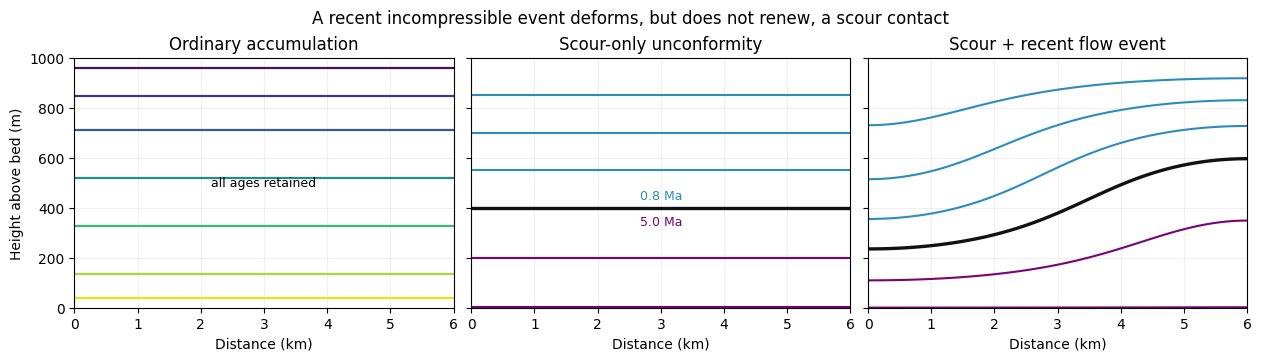

In [5]:
young_color = "#2b8cbe"
old_color = "#7a0177"
contact_color = "#111111"
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5), sharey=True, constrained_layout=True)

# Ordinary accumulation: a continuous age sequence.
ordinary_ages = np.array([0.2, 0.8, 1.5, 2.5, 3.5, 4.5, 5.0])
for age in ordinary_ages:
    z = H * (1 - age / 5.2)
    axes[0].plot([0, L / 1000], [z, z], color=plt.cm.viridis(age / 5.2), lw=1.6)
axes[0].text(3.0, 500, "all ages retained", ha="center", va="center", fontsize=9)
axes[0].set_title("Ordinary accumulation")

# Scour-only: plot the two age packets independently.
for age, z in zip(young_ages[:-1], young_z[:-1]):
    axes[1].plot([0, L / 1000], [z, z], color=young_color, lw=1.5)
for age, z in zip(old_ages[1:], old_z[1:]):
    axes[1].plot([0, L / 1000], [z, z], color=old_color, lw=1.5)
axes[1].plot([0, L / 1000], [contact_z, contact_z], color=contact_color, lw=2.4)
axes[1].text(3.0, contact_z + 35, "0.8 Ma", color=young_color, ha="center", fontsize=9)
axes[1].text(3.0, contact_z - 70, "5.0 Ma", color=old_color, ha="center", fontsize=9)
axes[1].set_title("Scour-only unconformity")

# Composite history: the same separately stored packets after recent deformation.
for (age, _, packet), line in zip(fine["specs"], fine["final_lines"]):
    if age in (young_age_ma, old_age_ma):
        continue
    axes[2].plot(line[:, 0] / 1000, line[:, 1], color=young_color if packet == "young" else old_color, lw=1.5)
axes[2].plot(fine_contact[:, 0] / 1000, fine_contact[:, 1], color=contact_color, lw=2.4)
axes[2].set_title("Scour + recent flow event")

for ax in axes:
    ax.set_xlim(0, L / 1000)
    ax.set_ylim(0, H)
    ax.set_xlabel("Distance (km)")
    ax.grid(alpha=0.18)
axes[0].set_ylabel("Height above bed (m)")
fig.suptitle("A recent incompressible event deforms, but does not renew, a scour contact")
plt.show()

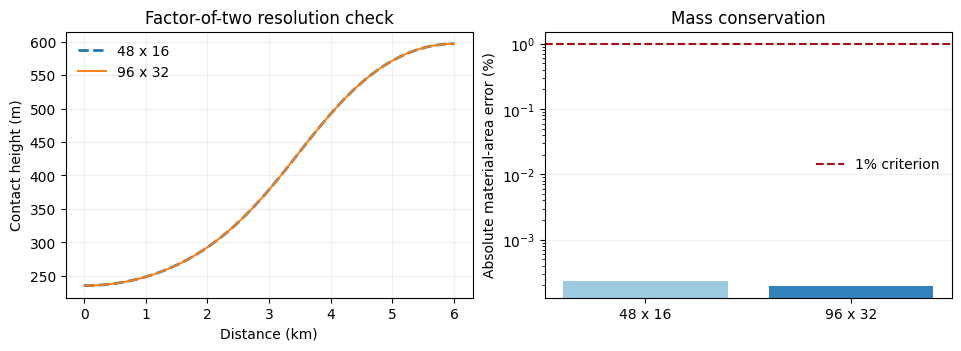

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), constrained_layout=True)
axes[0].plot(coarse_contact[:, 0] / 1000, coarse_contact[:, 1], "--", lw=2, label="48 x 16")
axes[0].plot(fine_contact[:, 0] / 1000, fine_contact[:, 1], lw=1.4, label="96 x 32")
axes[0].set(xlabel="Distance (km)", ylabel="Contact height (m)", title="Factor-of-two resolution check")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

area_errors = np.abs([coarse["area_error_percent"], fine["area_error_percent"]])
axes[1].bar(["48 x 16", "96 x 32"], area_errors, color=["#9ecae1", "#3182bd"])
axes[1].axhline(1.0, color="#a50f15", ls="--", label="1% criterion")
axes[1].set_yscale("log")
axes[1].set(ylabel="Absolute material-area error (%)", title="Mass conservation")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.2)
plt.show()

## Interpretation

The prescribed scour removes a 4.2 Myr interval, so it satisfies the missing-age constraint by construction. If accumulation resumed when the 0.8 Ma layer was deposited, however, the material contact is 800 kyr old. Its diffusive width would be approximately 5.2 times that of a 30 kyr contact for the same effective diffusivity. Scour-only therefore fails the stated sharpness constraint in this timing.

The recent perturbation produces about 0.36 km of contact relief. Doubling the finite-element resolution changes the final contact position by less than 0.1 m, and the material-area error is far below 1%. Nevertheless, incompressible deformation is a one-to-one material map. It changes the orientation of the contact but leaves the same old and young particles adjacent; the juxtaposition clock remains 800 kyr, not 20 kyr.

A viable composite history therefore requires renewed removal or truncation during the recent event. If such removal first exposed the two packets at 20 ka, the diffusion clock would be at most 20 kyr even though the missing-age interval remained 4.2 Myr. That extra topological operation is a necessary condition, not a result of the present flow calculation.

This toy model establishes the distinction between hiatus duration and contact age, and it shows that smooth deformation alone cannot reset contact age. It cannot establish whether Allan Hills stresses can generate the prescribed flow, whether surface ablation can remove the required intervening material, or whether the calculated contact geometry matches radar observations. The next minimal calculation should include an explicit free surface with a localized ablation boundary and should date when individual old and young surface segments first meet.